In [1]:
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.preprocessing import LabelEncoder

In [5]:
embedding_cache = torch.load("smiles_embeddings.pt")
df = pd.read_csv("dataset/final_processed_data.csv")
emb_s1 = torch.stack([embedding_cache[s] for s in df["SMILES1"]])
emb_s2 = torch.stack([embedding_cache[s] for s in df["SMILES2"]])

In [13]:
combined_embeddings = []

for e1, e2 in zip(emb_s1, emb_s2):
    combined_embeddings.append(torch.cat((e1, e2), dim=0))  # better than + (torch.cat((e1, e2), dim=0)) OR (torch.add(e1, e2))

combined_embeddings = torch.stack(combined_embeddings)

In [14]:
from sklearn.preprocessing import normalize

embeddings_np = combined_embeddings.numpy()
embeddings_np = normalize(embeddings_np)

In [15]:
sample_size = 5000  # keep <= 10k
indices = np.random.choice(len(embeddings_np), sample_size, replace=False)

emb_sample = embeddings_np[indices]
labels_sample = df["Side Effect Name"].iloc[indices]

In [16]:
labels_simple = [
    eval(x)[0] if isinstance(x, str) and len(eval(x)) > 0 else "None"
    for x in labels_sample
]

le = LabelEncoder()
labels_encoded = le.fit_transform(labels_simple)

In [17]:
pca = PCA(n_components=50)
emb_pca = pca.fit_transform(emb_sample)

In [18]:
tsne = TSNE(
    n_components=2,
    perplexity=30,
    n_iter=1000,
    random_state=42,
    verbose=1
)

emb_2d = tsne.fit_transform(emb_pca)

[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 5000 samples in 0.002s...
[t-SNE] Computed neighbors for 5000 samples in 0.162s...
[t-SNE] Computed conditional probabilities for sample 1000 / 5000
[t-SNE] Computed conditional probabilities for sample 2000 / 5000
[t-SNE] Computed conditional probabilities for sample 3000 / 5000
[t-SNE] Computed conditional probabilities for sample 4000 / 5000
[t-SNE] Computed conditional probabilities for sample 5000 / 5000
[t-SNE] Mean sigma: 0.105136
[t-SNE] KL divergence after 250 iterations with early exaggeration: 88.124092
[t-SNE] KL divergence after 1000 iterations: 1.947931


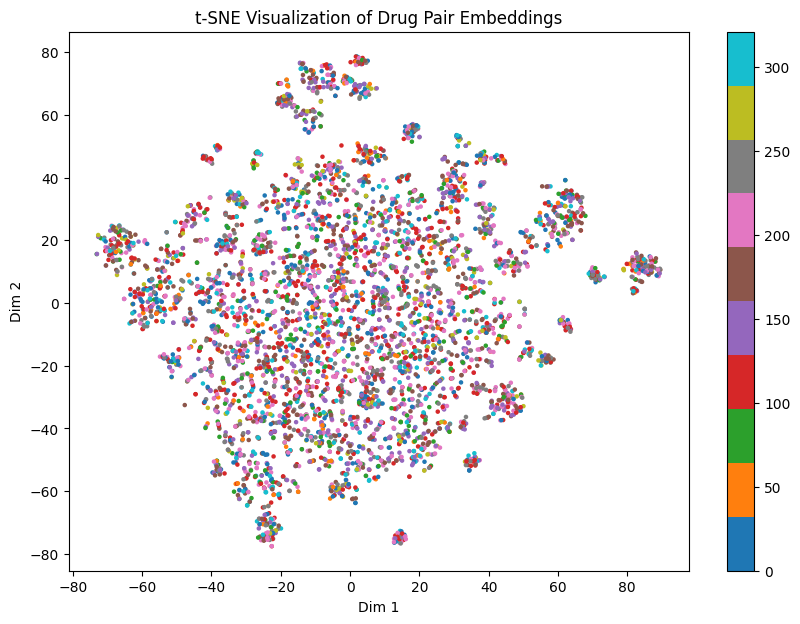

In [19]:
plt.figure(figsize=(10, 7))

scatter = plt.scatter(
    emb_2d[:, 0],
    emb_2d[:, 1],
    c=labels_encoded,
    cmap='tab10',
    s=5
)

plt.title("t-SNE Visualization of Drug Pair Embeddings")
plt.xlabel("Dim 1")
plt.ylabel("Dim 2")

plt.colorbar(scatter)
plt.show()